# Semantic segmentation of parking space with SAM3

## Preprocessing
- Install libraries via conda through provided yml file
    - Geospatial data handling
        - Rasterio (raster data)
        - Geopandas (vector data)
        - Shapely
    - Deep learning
        - Torch
        - Torch vision
        - Torch audio
    - SAM3
    Install from GitHub repo
    - Utility and augmentation
        - Numpy (array and vectorization)
        - Scipy (math operation handler)
        - Scikit-image
        - Albumentation (augmentation)
        - Tqdm (progress bar)
    - Visualization
        - Matplotlib
        - Folium
        - Ipywidgets

- Installation
    - Download Miniconda installer: 
    wget https://repo.anaconda.com/miniconda/Miniconda3-latest-Linux-x86_64.sh

    - Install in your home directory: 
    bash Miniconda3-latest-Linux-x86_64.sh -b -p $HOME/miniconda3

    - Initialize: 
    echo 'export PATH="$HOME/miniconda3/bin:$PATH"' >> ~/.bashrc
    source ~/.bashrc

    - Create environment with Python 3.12: 
    conda create -n <env_name> python=3.12

    - Activate: 
    conda activate <env_name>

    - Install ipykernel: 
    pip install ipykernel

    - Register env: 
    python -m ipykernel install --user --name=<env_name> --display-name="Python 3.11 (<env_name>)"

## Import libraries

In [1]:
# Load only from python 3.12
import sys

sys.path = [p for p in sys.path if "python3.8" not in p]

In [3]:
# Uncomment for package installation
# !{sys.executable} -m pip install transformers

In [2]:
import requests
import geopandas as gpd
import os
import subprocess
import math
from shapely.geometry import shape, box
import pandas as pd
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from requests import Request
from owslib.wfs import WebFeatureService
import torch
from PIL import Image
from sam3.model_builder import build_sam3_image_model
from sam3.model.sam3_image_processor import Sam3Processor
from sam3.model.geometry_encoders import Prompt          # geometric prompt wrapper
from sam3.model.data_misc import BatchedDatapoint
from pathlib import Path
import random
import cv2
from tqdm import tqdm
import csv
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from transformers import Sam3Processor, Sam3Model
import glob
from rasterio.merge import merge
import shutil
import json

/home/jovyan/miniconda3/envs/parking/lib/python3.12/site-packages/sam3/model_builder.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## Data acquisition

The following scripts execute the data acquisition and spatial alignment workflow:
### Amsterdam boundary
Retrieves the Amsterdam municipal boundary geometry from the PDOK WFS (vector).

### Referenced data
Queries the BGT API for parkeervlak (parking area) polygons within the boundary and clips them to the Amsterdam boundary.

### Aerial imagery: Luchfoto RGB via PDOK
PDOK provides two resolution:
| Layer ID                    | GSD   | Use case                             |
| --------------------------- | ----- | ----------------------------------------- |
| 2025_ortho25 / 2024_ortho25 | 25 cm | Good starting point, other countries might have similar resolution     |
| 2025_orthoHR / 2024_orthoHR | 8 cm  | Highest detail for small object detection, but only few countries have such high detail |

Start with 25cm resolution. Parking space with width of ~2m is visible in ~8px. Generates a spatial grid (512x512 px at 25cm GSD). For each spatial chip, it downloads RGB aerial imagery from the PDOK WMS and rasterizes the intersecting parking polygons into a binary mask. The rasterization strictly uses the downloaded image's affine transform to guarantee 1:1 pixel alignment.

### Main Notebook Cell
Checks for existing local files and execute the standalone scripts if data is missing.

## Authentication

In [ ]:
from huggingface_hub import login

with open("token.json") as f:
    token = json.load(f)
hf_token = token["hf_token"]

login(token=hf_token)

In [ ]:
# Authentication
from huggingface_hub import hf_hub_download
hf_hub_download(repo_id="facebook/sam3", filename="config.json")

'/home/jovyan/.cache/huggingface/hub/models--facebook--sam3/snapshots/3c879f39826c281e95690f02c7821c4de09afae7/config.json'

In [3]:
# Check data existence. Perform data acquisition if data does not exist
# Define expected outputs
data_dir = "data"
boundary_file = os.path.join(data_dir, "ams_boundary.gpkg")
parking_file = os.path.join(data_dir, "parking_space.gpkg", layer="combined")
imagery_dir = os.path.join(data_dir, "ams_imagery", "images")

# 1. Check and run Boundary extraction
if not os.path.exists(boundary_file):
    print("Boundary file not found. Performing data acquisition...")
    subprocess.run(["python", "scripts/ams_boundary.py"], check=True)
else:
    print("Amsterdam boundary already exists.")

# 2. Check and run Parkeervlak extraction
if not os.path.exists(parking_file):
    print("Parking vector file not found. Performing data acquisition...")
    subprocess.run(["python", "scripts/bgt_parking_space.py"], check=True)
else:
    print("Parkeervlak vector data already exists.")

# 3. Check and run Imagery/Mask generation
# We check if the directory exists and has files in it
if not os.path.exists(imagery_dir) or len(os.listdir(imagery_dir)) == 0:
    print("Imagery/Masks not found. Performing data acquisition...")
    subprocess.run(["python", "scripts/ams_imagery_v2.py"], check=True)
else:
    print(f"Imagery and masks already generated in {imagery_dir}.")

print("Data acquisition complete.")

Amsterdam boundary already exists.
Parkeervlak vector data already exists.
Imagery and masks already generated in data/ams_imagery/images.
Data acquisition complete.


In [9]:
# Check image validity (throw images with very little parking space)
def filter_chips(threshold=0.001):
    """
    Filters chips based on the fraction of parking pixels.
    threshold: Minimum fraction of positive pixels required to keep the chip (0.001 = 0.1%).
    """
    mask_dir = "data/ams_imagery/masks"
    image_dir = "data/ams_imagery/images"
    output_csv = "data/ams_imagery/valid_chips.csv"
    
    if not os.path.exists(mask_dir):
        raise FileNotFoundError(f"Mask directory not found: {mask_dir}")

    mask_files = [f for f in os.listdir(mask_dir) if f.endswith('.tif')]
    valid_chips = []

    print(f"Analyzing {len(mask_files)} masks for parking pixel fractions...")
    
    for mask_file in tqdm(mask_files, desc="Filtering chips"):
        mask_path = os.path.join(mask_dir, mask_file)
        # Reconstruct corresponding image filename
        image_file = mask_file.replace('_mask.tif', '.tif')
        image_path = os.path.join(image_dir, image_file)

        # Check if paired image actually exists
        if not os.path.exists(image_path):
            continue

        with rasterio.open(mask_path) as src:
            mask_data = src.read(1)

        total_pixels = mask_data.size
        parking_pixels = np.count_nonzero(mask_data)
        fraction = parking_pixels / total_pixels

        if fraction >= threshold:
            valid_chips.append({
                'image_path': image_path,
                'mask_path': mask_path,
                'fraction': f"{fraction:.6f}"
            })

    # Save registry of valid chips
    with open(output_csv, 'w', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=['image_path', 'mask_path', 'fraction'])
        writer.writeheader()
        writer.writerows(valid_chips)

    print(f"Filtering complete. Kept {len(valid_chips)}/{len(mask_files)} chips.")
    print(f"Saved training registry to: {output_csv}")

if __name__ == "__main__":
    # 0.1% threshold means at least 262 pixels in a 512x512 chip must be parking
    filter_chips(threshold=0.001)

Analyzing 26934 masks for parking pixel fractions...


Filtering chips: 100%|██████████| 26934/26934 [03:00<00:00, 149.20it/s]


Filtering complete. Kept 8296/26934 chips.
Saved training registry to: data/ams_imagery/valid_chips.csv


## Model

In [3]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Load HF processor and model
processor = Sam3Processor.from_pretrained("facebook/sam3")
model = Sam3Model.from_pretrained("facebook/sam3",
                                  torch_dtype=torch.bfloat16
                                 ).to(DEVICE)

# Freeze the heavy vision encoder to save memory
for param in model.vision_encoder.parameters():
    param.requires_grad = False

# Unfreeze geometry encoder and mask decoder
for param in model.mask_decoder.parameters():
    param.requires_grad = True
for param in model.geometry_encoder.parameters():
    param.requires_grad = True

Loading weights:   0%|          | 0/1468 [00:00<?, ?it/s]

In [4]:
# Create a parking dataset. Pytorch doesn't natively support Geotiff, so custom class is used to read the data
class ParkingDataset(Dataset):
    def __init__(self, csv_file, split='train', transform=None):
        self.split = split
        self.transform = transform
        self.samples = []
        
        # Read valid chips registry
        with open(csv_file, 'r') as f:
            reader = csv.DictReader(f)
            all_records = list(reader)

        # Determine spatial split thresholds dynamically based on Y-coordinates
        y_coords = []
        for row in all_records:
            with rasterio.open(row['image_path']) as src:
                y_coords.append(src.bounds.bottom)
        
        y_min, y_max = min(y_coords), max(y_coords)
        y_range = y_max - y_min
        
        # Split: South (Test: bottom 25%), Center (Val: next 25%), North (Train: top 50%)
        val_thresh = y_min + (y_range * 0.25)
        train_thresh = y_min + (y_range * 0.50)

        # Filter records based on requested split
        for row, y in zip(all_records, y_coords):
            if y < val_thresh and split == 'test':
                self.samples.append(row)
            elif val_thresh <= y < train_thresh and split == 'val':
                self.samples.append(row)
            elif y >= train_thresh and split == 'train':
                self.samples.append(row)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path = self.samples[idx]['image_path']
        mask_path = self.samples[idx]['mask_path']

        # Read image (Rasterio reads as CHW, swap to HWC for Albumentations)
        with rasterio.open(img_path) as src:
            image = src.read()
            image = np.transpose(image, (1, 2, 0))

        # Read mask
        with rasterio.open(mask_path) as src:
            mask = src.read(1)

        # Apply augmentations
        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']
        else:
            # Default PyTorch tensor conversion if no transforms applied
            image = torch.from_numpy(image.transpose(2, 0, 1)).float() / 255.0
            mask = torch.from_numpy(mask).long()

        return image, mask

In [5]:
def get_dataloaders(csv_file, batch_size=8):
    # Define augmentations (training only)
    train_transform = A.Compose([
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomRotate90(p=0.5),
        A.ColorJitter(brightness=0.2, contrast=0.2, hue=0.1, p=0.5),
        A.GaussNoise(var_limit=(10.0, 50.0), p=0.3),
        ToTensorV2()
    ])

    val_test_transform = A.Compose([
        ToTensorV2()
    ])

    # Instantiate datasets
    train_dataset = ParkingDataset(csv_file, split='train', transform=train_transform)
    val_dataset = ParkingDataset(csv_file, split='val', transform=val_test_transform)
    test_dataset = ParkingDataset(csv_file, split='test', transform=val_test_transform)

    # Create DataLoaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4)

    return train_loader, val_loader, test_loader

In [7]:
if __name__ == "__main__":
    csv_path = "data/ams_imagery/valid_chips.csv"
    train_loader, val_loader, test_loader = get_dataloaders(csv_path, batch_size=4)
    print(f"Train batches: {len(train_loader)}")
    print(f"Val batches: {len(val_loader)}")
    print(f"Test batches: {len(test_loader)}")

/tmp/ipykernel_2183/4154547089.py:8: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10.0, 50.0), p=0.3),


Train batches: 956
Val batches: 627
Test batches: 491


## Semantic segmentation

In [6]:
def predict_semantic_mask(processor, model, images, text_prompts=None):
    """Runs the forward pass to extract semantic segmentation masks."""
    # Default prompt to target our specific class
    if text_prompts is None:
        text_prompts = ["surface parking lot"] * len(images)
        
    # Processor handles resizing and normalization
    inputs = processor(
        images=images, 
        text=text_prompts, 
        return_tensors="pt"
    ).to(model.device)
    
    outputs = model(**inputs)
    
    # Extract the native semantic segmentation output [batch, 1, H, W]
    return outputs.semantic_seg

In [7]:
# Dice loss alongside BCE for sparse label
def dice_loss(logits, targets, smooth=1e-6):
    probs = torch.sigmoid(logits)
    inter = (probs * targets).sum(dim=(2, 3))
    union = probs.sum(dim=(2, 3)) + targets.sum(dim=(2, 3))
    return 1.0 - ((2 * inter + smooth) / (union + smooth)).mean()

In [8]:
def train_sam3(processor, model, train_loader, val_loader, num_epochs=10, lr=1e-4):
    """Executes the training and validation loop for the SAM3 semantic head."""
    device = model.device
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    pos_weight = torch.tensor([15.0]).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
        
    for epoch in range(num_epochs):
        # --- Training Phase ---
        model.train()
        train_loss = 0.0
        
        train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]")
        for images, masks in train_pbar:
            masks = masks.to(device, dtype=torch.float32).unsqueeze(1)
            images_list = [img.permute(1, 2, 0).cpu().numpy() for img in images]
            
            optimizer.zero_grad()
            
            # 1. Cast forward pass to mixed precision (bfloat16)
            with torch.amp.autocast("cuda", dtype=torch.bfloat16):
                logits = predict_semantic_mask(processor, model, images_list)
                
                if logits.shape[2:] != masks.shape[2:]:
                    logits = F.interpolate(logits, size=masks.shape[2:], mode='bilinear', align_corners=False)
                
                loss = 0.5 * criterion(logits, masks) + 0.5 * dice_loss(logits, masks)
            
            # 2. Standard backward and step (No scaling needed for bfloat16)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            train_pbar.set_postfix({'loss': f"{loss.item():.4f}"})
            
        avg_train_loss = train_loss / len(train_loader)
        
        # --- Validation Phase ---
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            val_pbar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]")
            for images, masks in val_pbar:
                masks = masks.to(device, dtype=torch.float32).unsqueeze(1)
                images_list = [img.permute(1, 2, 0).cpu().numpy() for img in images]
                
                with torch.amp.autocast("cuda", dtype=torch.bfloat16):
                    logits = predict_semantic_mask(processor, model, images_list)
                    if logits.shape[2:] != masks.shape[2:]:
                        logits = F.interpolate(logits, size=masks.shape[2:], mode='bilinear', align_corners=False)
                    loss = 0.5 * criterion(logits, masks) + 0.5 * dice_loss(logits, masks)
                    
                val_loss += loss.item()
                
        avg_val_loss = val_loss / len(val_loader)
        print(f"Epoch {epoch+1} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

    torch.save(model.state_dict(), "data/sam3_parking_finetuned.pth")
    print("Training complete!")

In [11]:
train_sam3(processor, model, train_loader, val_loader)

Epoch 1/10 [Val]: 100%|██████████| 627/627 [10:25<00:00,  1.00it/s]


Epoch 1 | Train Loss: 0.7718 | Val Loss: 0.7546


Epoch 2/10 [Val]: 100%|██████████| 627/627 [10:26<00:00,  1.00it/s]


Epoch 2 | Train Loss: 0.7276 | Val Loss: 0.7512


Epoch 3/10 [Val]: 100%|██████████| 627/627 [10:33<00:00,  1.01s/it]


...

Epoch 8 | Train Loss: 0.6558 | Val Loss: 0.7013


Epoch 9/10 [Val]: 100%|██████████| 627/627 [10:24<00:00,  1.00it/s]


Epoch 9 | Train Loss: 0.6504 | Val Loss: 0.6819


Epoch 10/10 [Val]: 100%|██████████| 627/627 [10:24<00:00,  1.00it/s]


Epoch 10 | Train Loss: 0.6437 | Val Loss: 0.6853
Training complete!


In [9]:
def run_inference_on_chips(processor, model, weights_path=None):
    """Runs the trained model on all downloaded chips and saves prediction rasters."""
    input_dir = "data/ams_imagery/images"
    output_dir = "data/ams_imagery/zero_shot"
    os.makedirs(output_dir, exist_ok=True)
    
    # Load fine-tuned weights
    # model.load_state_dict(torch.load(weights_path, map_location=model.device))
    
    # Load fine‑tuned weights only if a path is given
    if weights_path is not None:
        model.load_state_dict(torch.load(weights_path, map_location=model.device))
    
    model.eval()
    
    image_files = glob.glob(os.path.join(input_dir, "*.tif"))
    print(f"Found {len(image_files)} chips for inference.")
    
    with torch.no_grad():
        for img_path in tqdm(image_files, desc="Predicting"):
            filename = os.path.basename(img_path)
            out_path = os.path.join(output_dir, filename.replace(".tif", "_pred.tif"))
            
            # Skip if already predicted (if the process gets interrupted)
            if os.path.exists(out_path):
                continue
                
            # Read image and spatial metadata
            with rasterio.open(img_path) as src:
                profile = src.profile
                # Read as [C, H, W] and convert to [H, W, C] for processor
                image = src.read()
                image_hwc = np.transpose(image, (1, 2, 0))
                
            # Run memory-efficient prediction
            with torch.amp.autocast("cuda", dtype=torch.bfloat16):
                # predict_semantic_mask expects a list of images
                logits = predict_semantic_mask(processor, model, [image_hwc])
                
                # Resize logits to original chip size if necessary
                target_size = (profile['height'], profile['width'])
                if logits.shape[2:] != target_size:
                    logits = F.interpolate(logits, size=target_size, mode='bilinear', align_corners=False)
                
                # Apply Sigmoid to convert logits to probabilities, then threshold at 0.5
                probs = torch.sigmoid(logits)
                binary_mask = (probs > 0.5).squeeze().cpu().numpy().astype(np.uint8)
                
            # Update profile for a single-channel binary mask
            profile.update(
                dtype=rasterio.uint8,
                count=1,
                compress='lzw'
            )
            
            # Save the predicted georeferenced mask
            with rasterio.open(out_path, 'w', **profile) as dst:
                dst.write(binary_mask, 1)

In [29]:
# Delete old prediction 
shutil.rmtree("data/ams_imagery/zero_shot", ignore_errors=True)
os.makedirs("data/ams_imagery/zero_shot")

In [10]:
run_inference_on_chips(processor, model)

Found 26934 chips for inference.


Predicting: 100%|██████████| 26934/26934 [4:38:16<00:00,  1.61it/s]   


In [19]:
# Stitch raster function
def stitch_rasters(input_dir, output_filepath, description="rasters"):
    """Merges all GeoTIFF chips in a directory into a single georeferenced mosaic."""
    files = glob.glob(os.path.join(input_dir, "*.tif"))
    if not files:
        print(f"No files found in {input_dir} to stitch.")
        return
        
    print(f"Stitching {len(files)} {description}... This might take a minute.")
    
    src_files_to_mosaic = [rasterio.open(fp) for fp in files]
    
    # Merge them (rasterio handles spatial alignment automatically)
    mosaic, out_trans = merge(src_files_to_mosaic)
    
    out_meta = src_files_to_mosaic[0].meta.copy()
    out_meta.update({
        "driver": "GTiff",
        "height": mosaic.shape[1],
        "width": mosaic.shape[2],
        "transform": out_trans,
        "compress": "lzw",
        "BIGTIFF": "YES"
    })
    
    with rasterio.open(output_filepath, "w", **out_meta) as dest:
        dest.write(mosaic)
        
    for src in src_files_to_mosaic:
        src.close()
        
    print(f"Success! {description.capitalize()} mosaic saved to {output_filepath}")

In [13]:
# Stitching config
# Define directories and outputs
# 512x512px images
ori_chips_dir = "data/ams_imagery/images"
pred_chips_dir = "data/ams_imagery/predictions"
mask_chips_dir = "data/ams_imagery/masks"

# Mosaic
ori_mosaic_path = "data/mosaic_imagery.tif"
pred_mosaic_path = "data/mosaic_predictions.tif"
mask_mosaic_path = "data/mosaic_masks.tif"


In [21]:
# Stich raster
stitch_rasters(pred_chips_dir, pred_mosaic_path, description="prediction_rasters")

Stitching 26934 prediction_rasters... This might take a minute.
Success! Prediction_rasters mosaic saved to data/mosaic_predictions.tif


In [22]:
stitch_rasters(mask_chips_dir, mask_mosaic_path, description="mask_rasters")

Stitching 26934 mask_rasters... This might take a minute.
Success! Mask_rasters mosaic saved to data/mosaic_masks.tif


## Performance metric (IoU)

#### Single image based IoU

In [11]:
def calculate_chip_iou(pred_dir, mask_dir):
    """Compute mean IoU across matched chip pairs."""
    iou_scores = []
    pred_files = glob.glob(os.path.join(pred_dir, "*_pred.tif"))

    for pred_path in tqdm(pred_files, desc="Computing IoU"):
        # Derive the matched mask filename from the prediction filename
        basename = os.path.basename(pred_path).replace("_pred.tif", "_mask.tif")
        mask_path = os.path.join(mask_dir, basename)

        if not os.path.exists(mask_path):
            continue  # skip chips without a paired mask

        with rasterio.open(pred_path) as p, rasterio.open(mask_path) as m:
            pred = (p.read(1) > 0)
            gt   = (m.read(1) > 0)

        # Skip chips with no parking in GT (would inflate IoU)
        if gt.sum() == 0:
            continue

        intersection = np.logical_and(pred, gt).sum()
        union        = np.logical_or(pred, gt).sum()
        iou_scores.append(intersection / union if union > 0 else 0.0)

    mean_iou = np.mean(iou_scores)
    print(f"Mean IoU over {len(iou_scores)} chips with parking: {mean_iou:.4f}")
    return mean_iou


In [14]:
# Apply
calculate_chip_iou("data/ams_imagery/zero_shot", mask_chips_dir) # zero-shot

Computing IoU: 100%|██████████| 26934/26934 [05:40<00:00, 79.07it/s]

Mean IoU over 8575 chips with parking: 0.0908


np.float64(0.09082969169064067)

In [15]:
# Apply
calculate_chip_iou("data/ams_imagery/predictions", mask_chips_dir)

Computing IoU: 100%|██████████| 26934/26934 [06:07<00:00, 73.27it/s] 

Mean IoU over 8575 chips with parking: 0.2287


np.float64(0.22874216104387354)

#### Mosaic based IoU

In [23]:
def calculate_mosaic_iou(pred_path, gt_path):
    """Calculates the Intersection over Union between the predicted and ground truth mosaics."""
    print("Calculating Global IoU...")
    
    with rasterio.open(pred_path) as pred_src, rasterio.open(gt_path) as gt_src:
        if pred_src.shape != gt_src.shape:
            print("Warning: Mosaics have different dimensions. IoU might be skewed.")
            
        # Read the stitched arrays into memory 
        pred_data = pred_src.read(1)
        gt_data = gt_src.read(1)
        
        # Ensure binary logic
        pred_bool = (pred_data > 0).astype(bool)
        gt_bool = (gt_data > 0).astype(bool)
        
        # Calculate overlap and union
        intersection = np.logical_and(pred_bool, gt_bool).sum()
        union = np.logical_or(pred_bool, gt_bool).sum()
        
        iou = intersection / union if union > 0 else 0.0
        
        print(f"Intersection (True Positives): {intersection:,} pixels")
        print(f"Union (Total Footprint):       {union:,} pixels")
        print(f"Global IoU:                    {iou:.4f} ({iou * 100:.2f}%)")
        
        return iou

In [25]:
calculate_mosaic_iou(pred_mosaic_path, mask_mosaic_path)

Calculating Global IoU...


ValueError: operands could not be broadcast together with shapes (69120,102912) (68608,102912) 

## Visual check

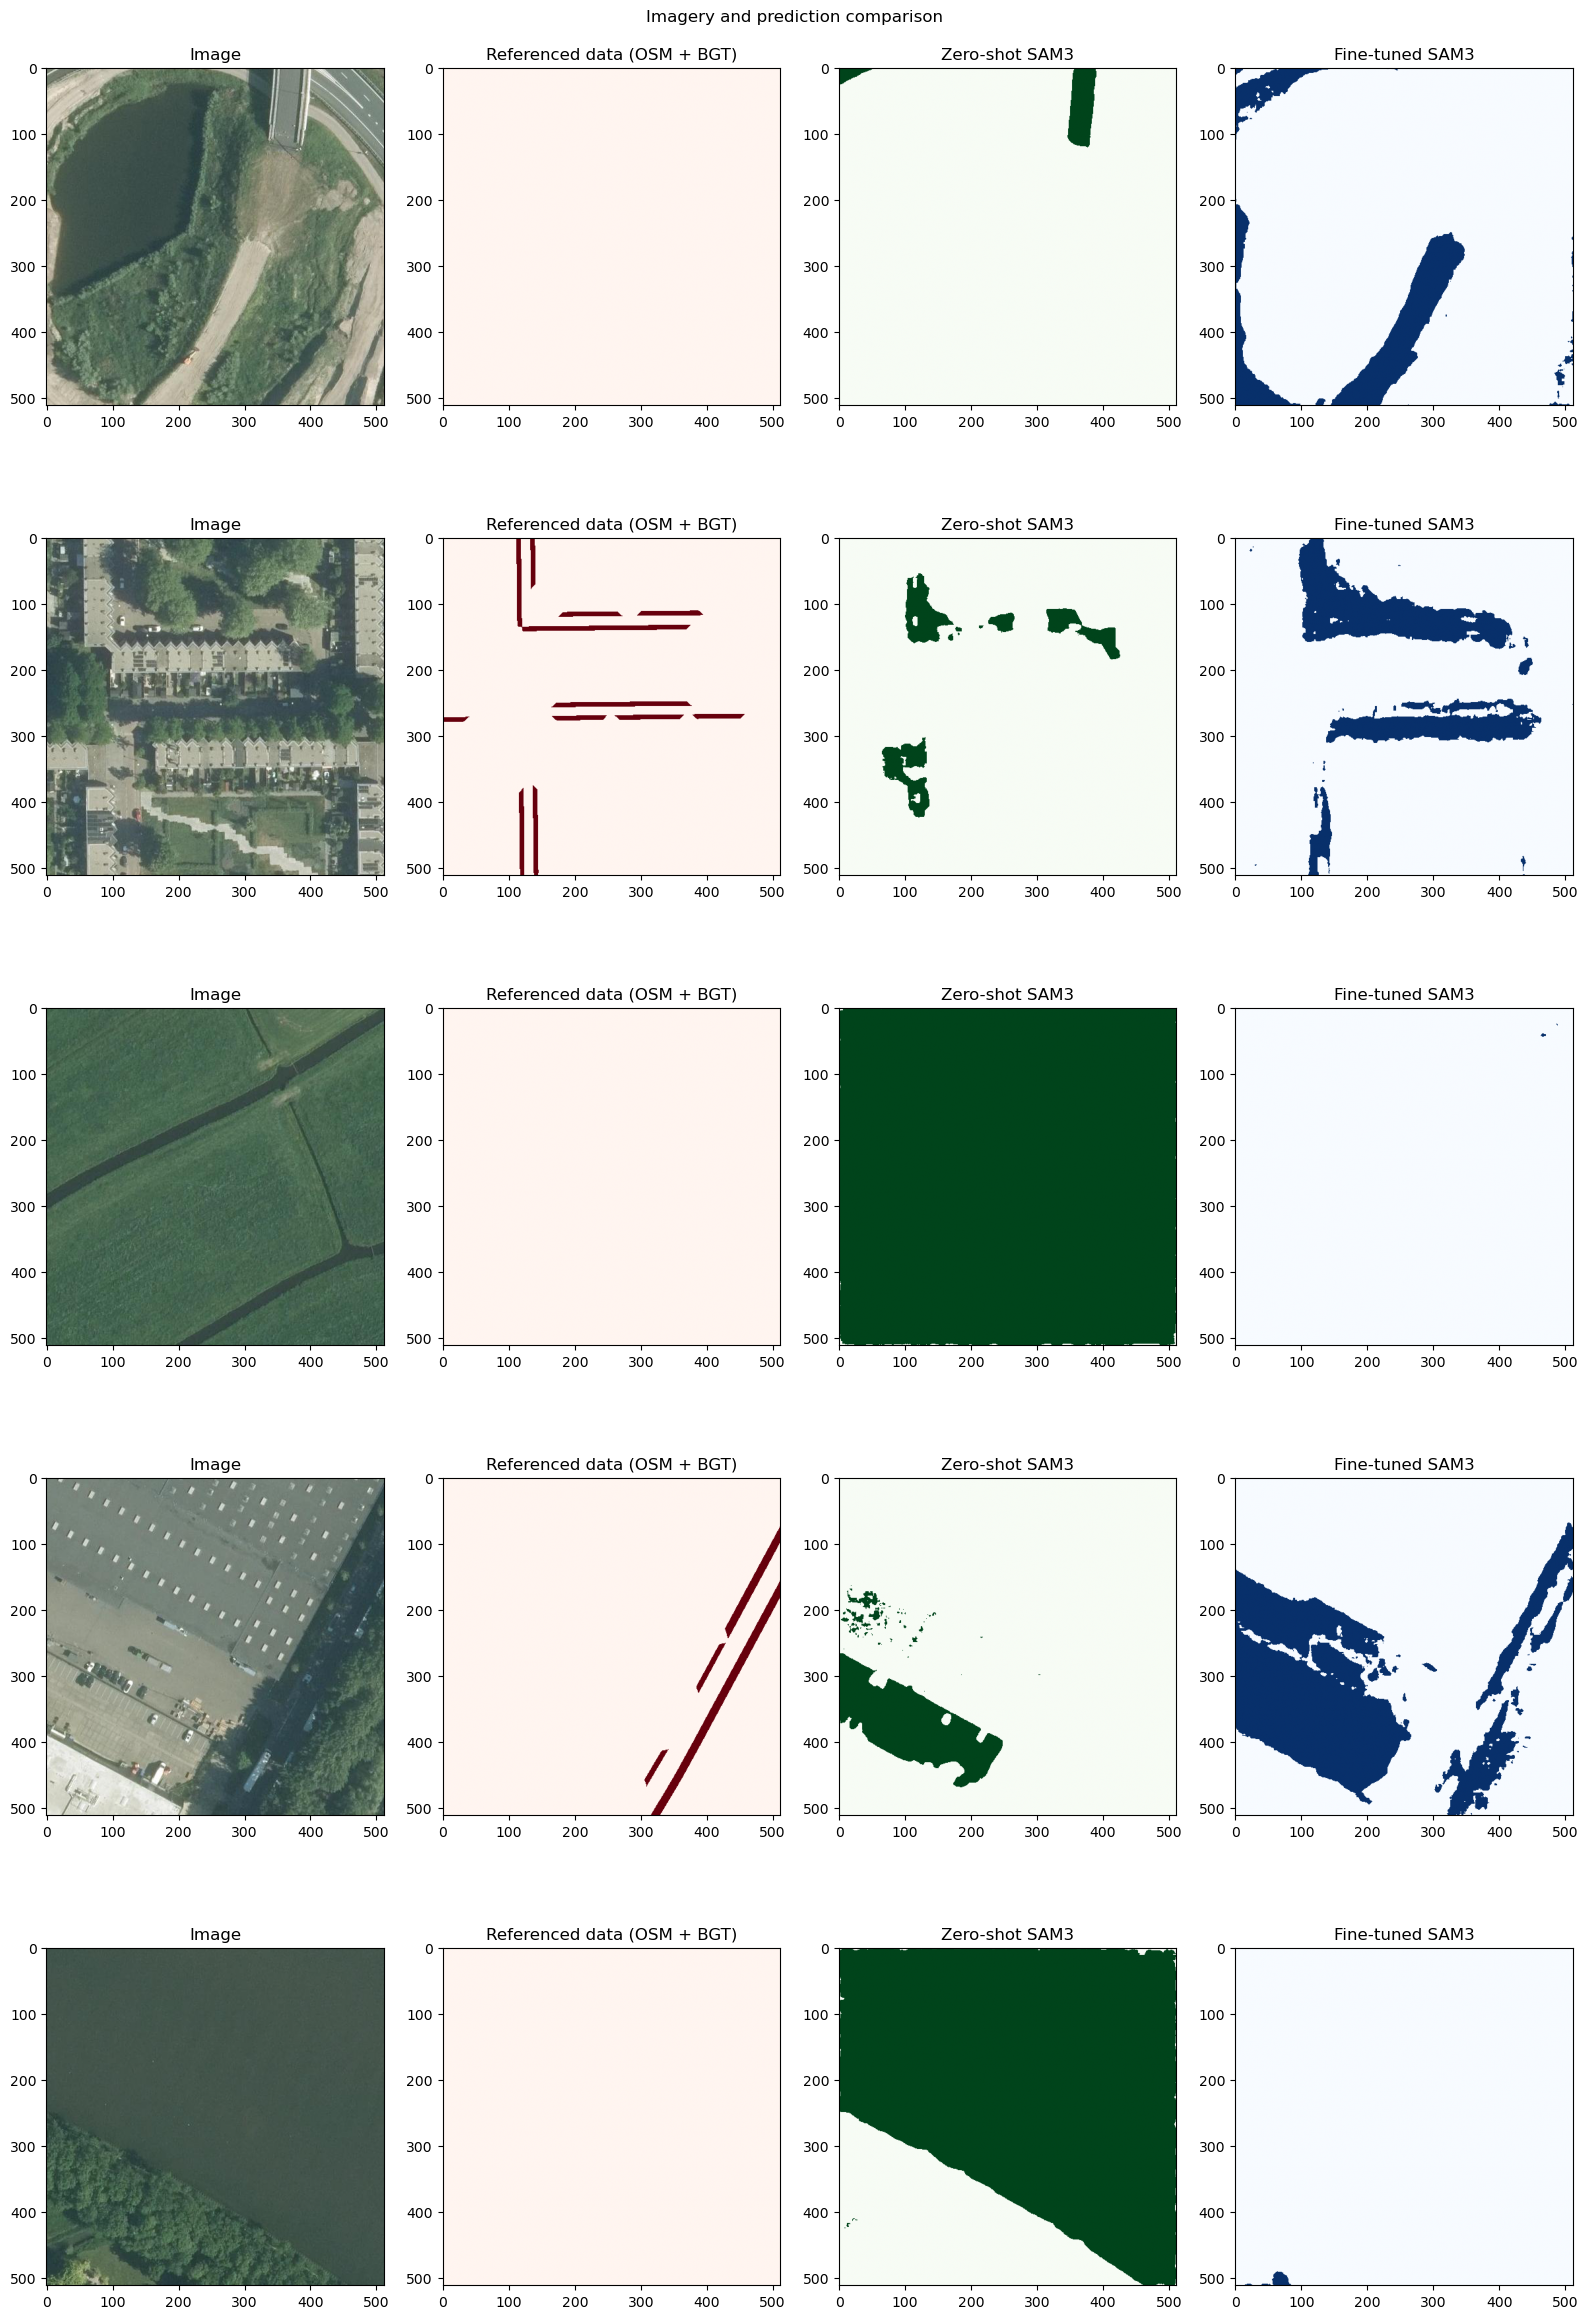

In [30]:
sample_files = random.sample(glob.glob("data/ams_imagery/predictions/*.tif"), 5)
fig, axes = plt.subplots(5, 4, figsize=(16, 24))

for i, pred_path in enumerate(sample_files):
    img_path = pred_path.replace("/predictions/", "/images/").replace("_pred.tif", ".tif")
    zs_path = pred_path.replace("/predictions/", "/zero_shot/")
    mask_path = pred_path.replace("/predictions/", "/masks/").replace("_pred.tif", "_mask.tif")
    
    with rasterio.open(pred_path) as src: pred = src.read(1)
    with rasterio.open(zs_path) as src: zs = src.read(1)
    with rasterio.open(img_path) as src: img = src.read().transpose(1,2,0)
    with rasterio.open(mask_path) as src: gt = src.read(1)
    
    axes[i,0].imshow(img); axes[i,0].set_title("Image")
    axes[i,1].imshow(gt, cmap="Reds"); axes[i,1].set_title("Referenced data (OSM + BGT)")
    axes[i,2].imshow(zs, cmap="Greens"); axes[i,2].set_title("Zero-shot SAM3")
    axes[i,3].imshow(pred, cmap="Blues"); axes[i,3].set_title("Fine-tuned SAM3")

fig.suptitle("Imagery and prediction comparison")
plt.tight_layout()
plt.savefig("prediction_comparison_v3.png", dpi=100)
plt.show()